# Current version : 9.D (2025-04-29)

In [3]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib as mpl

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['#EE2A35', '#009736',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [ ]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('data/cyc_analysis_nonzero_circa2.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('data/cyc_analysis_nonzero_circa4.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


# Cycling genes

## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [132]:
import pandas as pd

dir_sum = '../R/Results/2025-06-25_circa4_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-25_circa4_cyc_siggene_by_celltype.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [133]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [134]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

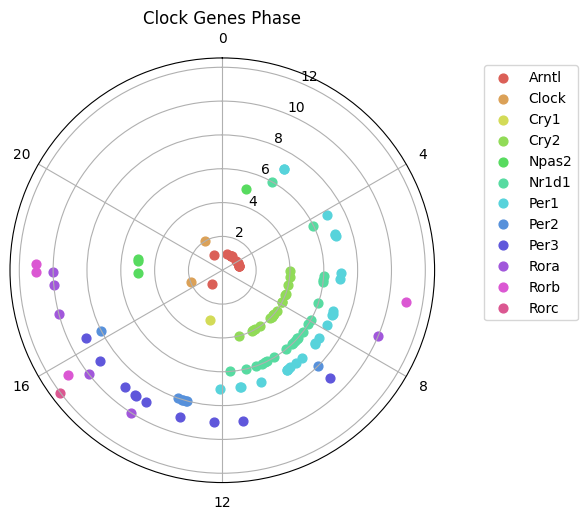

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate = "2025-06-25_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_by_celltype.xlsx', sheet_name=None)
cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_count_by_celltype.csv', index_col='cycling_gene_count')

In [ ]:
cycling_summary.iloc[1]

In [ ]:
for idx, celltype in enumerate(df_all.keys()):

    # Data preparation
    df = pd.DataFrame(data=zip(df_all[celltype]['CycID'], df_all[celltype]['meta2d_phase']))
    df.columns = ['Gene','Phase']
    df['Radians'] = df['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df['Radians'], bins = 24)

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.savefig(f'Gallery/circa4/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'data/{region}_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [365]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [366]:
run_namdate_1 = "2025-06-26_circa4"
run_namdate_2 = "2025-06-26_SD1"
run_type = 'celltype'
cell_type_plot = 'Astro TE'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [367]:
from module.misc import genes_list

gene_list_plot = genes_list("clock")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [368]:
data = pd.DataFrame(index=gene_list_plot)

In [369]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [370]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
# data.dropna(inplace= True)
data['Gene'] = data.index
data['Diff'] = data['NS'] - data['SD']
data = data.sort_values(by='NS')

In [371]:

data['NS2'] = data['NS']
data['SD2'] = data['SD']

# for n in range(len(data)):
#     if data.iloc[n,data.columns.get_loc("Diff")] > 12:
#         if data.iloc[n,data.columns.get_loc("NS")] < data.iloc[n,data.columns.get_loc("SD")]:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")] + 24
#         else:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
#     else:
#         data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]
#         data.iloc[n,data.columns.get_loc("SD")] = data.iloc[n,data.columns.get_loc("SD")]
thres = 12

for n in range(len(data)):
    if (abs(data.iloc[n,data.columns.get_loc("Diff")]) >= thres):
        if (data.iloc[n,data.columns.get_loc("SD")] > data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]-24
        elif (data.iloc[n,data.columns.get_loc("SD")] < data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
    else:
        data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]
        data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]

# data = data.sort_values(by="Diff", ascending=False)
data = data.sort_index()

In [372]:
data

,NS,SD,Gene,Diff,NS2,SD2
Arntl,1.000053,NaN,Arntl,NaN,1.000053,NaN
Clock,NaN,NaN,Clock,NaN,NaN,NaN
Cry1,NaN,NaN,Cry1,NaN,NaN,NaN
Cry2,7.867642,4.905707,Cry2,2.961935,7.867642,4.905707
Npas2,18.502112,NaN,Npas2,NaN,18.502112,NaN
Nr1d1,9.087505,6.734954,Nr1d1,2.352552,9.087505,6.734954
Per1,8.328822,NaN,Per1,NaN,8.328822,NaN
Per2,NaN,NaN,Per2,NaN,NaN,NaN
Per3,11.481614,7.566277,Per3,3.915337,11.481614,7.566277
Rora,NaN,7.239505,Rora,NaN,NaN,7.239505


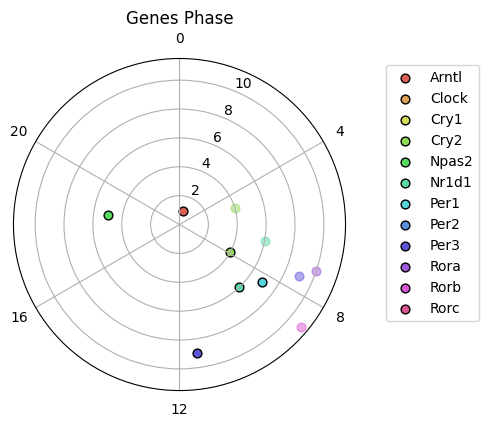

In [373]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors='black')
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [374]:
# Color palette
gene_order = data.index
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [375]:
# data = data[0:20]

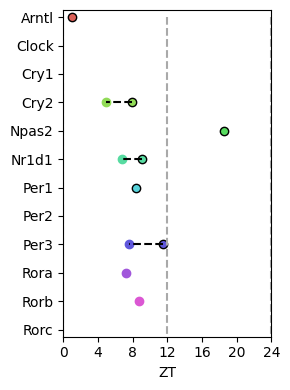

In [376]:
plt.figure(figsize=(3,4))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS2")], xmax=data.iloc[n,data.columns.get_loc("SD2")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS2")],y=n,
               color = data.iloc[n,data.columns.get_loc("Color")],
                 edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD2")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = [0,12,24], ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [27]:
df_gen_NS = pd.read_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv', index_col="Celltype")
df_gen_SD = pd.read_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv', index_col="Celltype")

In [28]:
df_gen_NS.to_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv')
df_gen_SD.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

In [29]:
run_namdate_1 = "2025-06-26_circa4"
run_namdate_2 = "2025-06-26_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_group.csv', index_col='celltype')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_group.csv', index_col='celltype')

In [30]:
NS_dict = dict(zip(cycling_summary_1.index,cycling_summary_1['cycling_gene_count']))
SD_dict = dict(zip(cycling_summary_2.index,cycling_summary_2['cycling_gene_count']))

df_gen_NS['Cycling_pval'] = df_gen_NS.index.map(NS_dict)
df_gen_SD['Cycling_pval'] = df_gen_SD.index.map(SD_dict)

In [38]:
df_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])
df_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])


common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    # df_NS[key] = df_NS[key][df_NS[key]['meta2d_BH.Q']>=0.05]
    # df_SD[key] = df_SD[key][df_SD[key]['meta2d_BH.Q']>=0.05]
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [39]:
sum_com_dict = dict(zip(sum_com_df['Gene'],sum_com_df['Common']))
df_gen_NS['Common_pval'] = df_gen_NS.index.map(sum_com_dict)
df_gen_SD['Common_pval'] = df_gen_SD.index.map(sum_com_dict)


In [40]:
df_NS_BH_nb = [len(df_NS[key]) for key in df_NS.keys()]
ddf_NS_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_NS_BH_nb}, index = df_NS.keys())

df_SD_BH_nb = [len(df_SD[key]) for key in df_SD.keys()]
ddf_SD_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_SD_BH_nb}, index = df_SD.keys())

NS_BH_dict = dict(zip(ddf_NS_BH_nb.index, ddf_NS_BH_nb['Expressed_genes']))
df_gen_NS['Cycling_BH'] = df_gen_NS.index.map(NS_BH_dict)

SD_BH_dict = dict(zip(ddf_SD_BH_nb.index, ddf_SD_BH_nb['Expressed_genes']))
df_gen_SD['Cycling_BH'] = df_gen_SD.index.map(SD_BH_dict)

In [41]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

In [44]:
df_gen_NS.sort_values(by='Common_pval',inplace=True)
df_gen_SD
df_gen_NS.dropna(axis=0, inplace= True)
df_gen_SD.dropna(axis=0, inplace= True)

Text(0.5, 1.0, 'Cycling genes in normal and disrupted sleep (pval)')

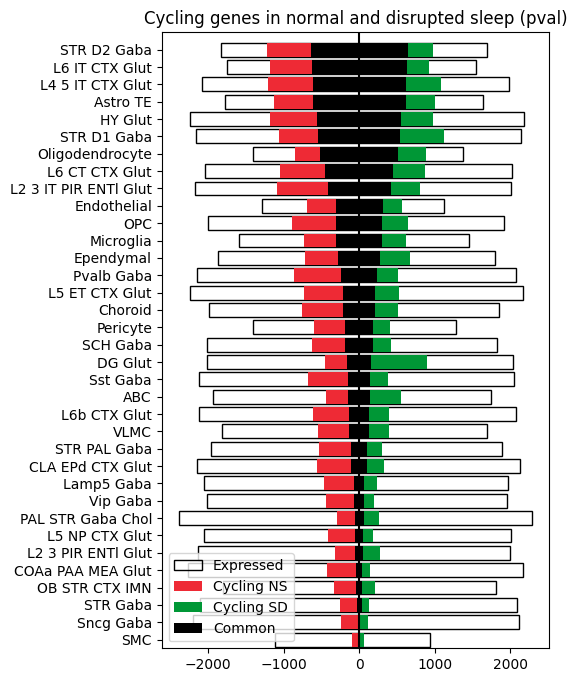

In [51]:
fig, ax = plt.subplots(figsize = (5,8))
ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Expressed_genes'], label = 'Expressed', color = 'None', edgecolor ='black')
ax.barh(y = df_gen_SD.index, width = df_gen_SD['Expressed_genes'], color = 'None', edgecolor = 'black')
ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Cycling_pval'], label = 'Cycling NS')
ax.barh(y = df_gen_SD.index, width= df_gen_SD['Cycling_pval'], label = 'Cycling SD')
ax.barh(y = df_gen_NS.index, width=df_gen_NS['Common_pval'], label = 'Common', color = 'black')
ax.barh(y = df_gen_SD.index, width=-df_gen_SD['Common_pval'], color = 'black')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep (pval)')

In [ ]:
len(df_gen_SD.index)

# Test Squidpy

In [377]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [378]:
adata = sc.read_h5ad('../notebook/h5ad/circa-SD/circa-SD_final.h5ad.gz')
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'


In [379]:
# df = pd.DataFrame(data=adata.X.toarray(), index=adata.obs_names, columns=adata.var_names)

# from module.xenium_preprocessing import add_annotations
# df = add_annotations(adata,df)
name_dir = 'circa-SD'
df.to_parquet(f"{dir_notebook}/csv/{name_dir}/{name_dir}_norm_combined.parquet")

AttributeError: 'dict' object has no attribute 'to_parquet'

In [ ]:
df.sample(3)

In [ ]:
adata = adata[adata.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='CTX']
adata.obsm['spatial'] = adata.obsm['coord_xy']

KeyError: 'coord_xy'

In [ ]:
adata

In [ ]:
sq.gr.spatial_neighbors(adata)

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="cell_type_final")

In [ ]:
sq.pl.nhood_enrichment(adata, cluster_key="cell type")

# Moran

In [ ]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata.uns["moranI"].head(15)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gfap",
        "Trem2",
        "Bhlhe22"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Folr1",
        "Slc17a7",
        "Rsph1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp1r1b",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
grp = adata.obs['run'].unique()
grp

In [ ]:
df2 = adata[adata.obs['run'] == 'circa4'].obs.groupby('sample')['region_automap_name'].value_counts()

In [ ]:
df2.to_csv('temp_region_circa4.csv')

# Test run R

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
a = 1
print(a)

# DEG

## Data import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
cell_nb = pd.read_csv('../notebook/analysis/circa-SD/summary_cell_number.csv')
cell_nb

,run,cell_type_final,count
0,SD1,Astro TE,177467
1,SD1,Oligodendrocyte,110406
2,SD1,L6 IT CTX Glut,76983
3,SD1,STR D2 Gaba,60143
4,SD1,Endothelial,49371
...,...,...,...
93,circa4,NLOT Glut,1017
94,circa4,PAL STR Gaba Chol,962
95,circa4,L2 3 IT RSP Glut,782
96,circa4,AD Glut,580


In [26]:
from module.misc import cell_class

dict_temp = cell_class()

cell_nb['cell_class'] = cell_nb['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")
cell_nb

,run,cell_type_final,count,cell_class
0,SD1,Astro TE,177467,Glial
1,SD1,Oligodendrocyte,110406,Glial
2,SD1,L6 IT CTX Glut,76983,Neuron
3,SD1,STR D2 Gaba,60143,Neuron
4,SD1,Endothelial,49371,Epithelial
...,...,...,...,...
93,circa4,NLOT Glut,1017,Neuron
94,circa4,PAL STR Gaba Chol,962,Neuron
95,circa4,L2 3 IT RSP Glut,782,Neuron
96,circa4,AD Glut,580,Neuron


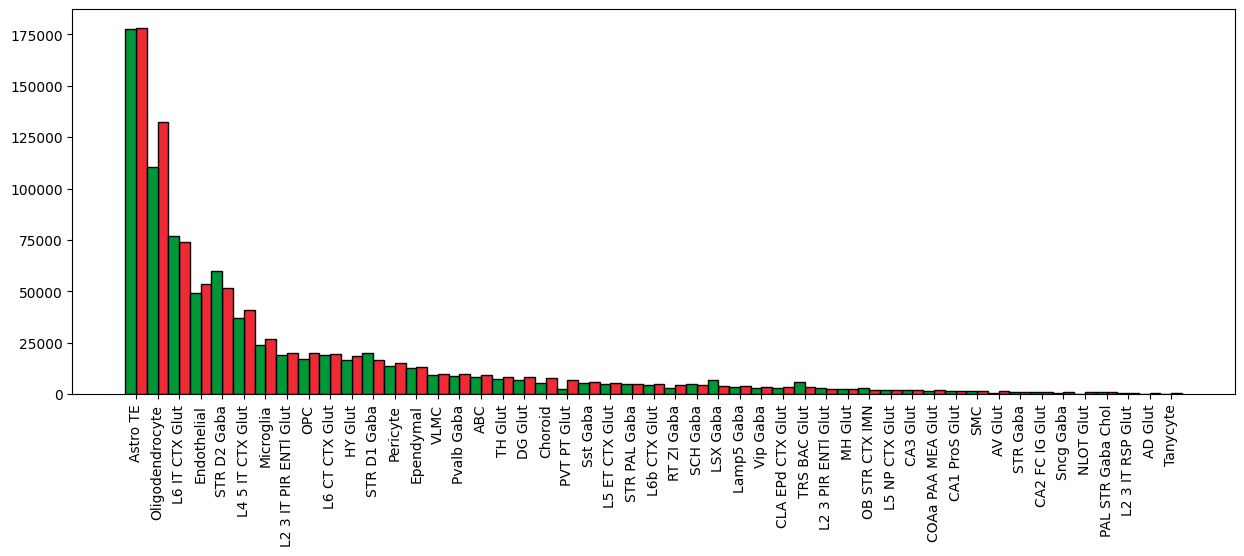

In [20]:
plt.figure(figsize=(15,5))
plt.bar(x=cell_nb['cell_type_final'][cell_nb['run']=='circa4'],
         height=cell_nb[cell_nb['run']=='circa4']['count'],
           width = 0.5, align='edge', edgecolor ='black')
plt.bar(x=cell_nb['cell_type_final'][cell_nb['run']=='SD1'],
         height=cell_nb[cell_nb['run']=='SD1']['count'],
           width = -0.5, align='edge', edgecolor ='black')
plt.xticks(ticks=cell_nb['cell_type_final'][cell_nb['run']=='SD1'], rotation=90)
plt.savefig('Gallery/circa-SD_cellnb.svg')

In [4]:
df_all = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if "SD1" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][df_all[key]['pct_nz_group']>0.1]
    df_all[key].index = df_all[key]['names']

In [22]:
df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

for key in df_filter.keys():
    df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
    df_filter[key].index = df_filter[key]['names']

In [5]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05) & (df_all[key]['pct_nz_group'] > 0.1) & (abs(df_all[key]['logfoldchanges']) > 0.26) ]
# df_filter['SCH'].sort_values(by='logfoldchanges')

## Quantif

In [6]:
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

,Celltype,Expressed,nb_DEG,Upregulated,Downregulated
Celltype,,,,,
Astro TE,Astro TE,1641,202,44,158
HY Glut,HY Glut,2186,321,159,162
Vip Gaba,Vip Gaba,1952,266,88,178
Sst Gaba,Sst Gaba,2052,318,117,201
Oligodendrocyte,Oligodendrocyte,1372,185,80,105
Endothelial,Endothelial,1121,136,32,104
Ependymal,Ependymal,1795,396,213,183
VLMC,VLMC,1685,198,83,115
SCH Gaba,SCH Gaba,1826,332,47,285


In [278]:
df_deg_quant.drop(['VLMC', "Ependymal"], axis = 0, inplace=True)

Text(0.5, 1.0, 'Differentially Expressed Genes')

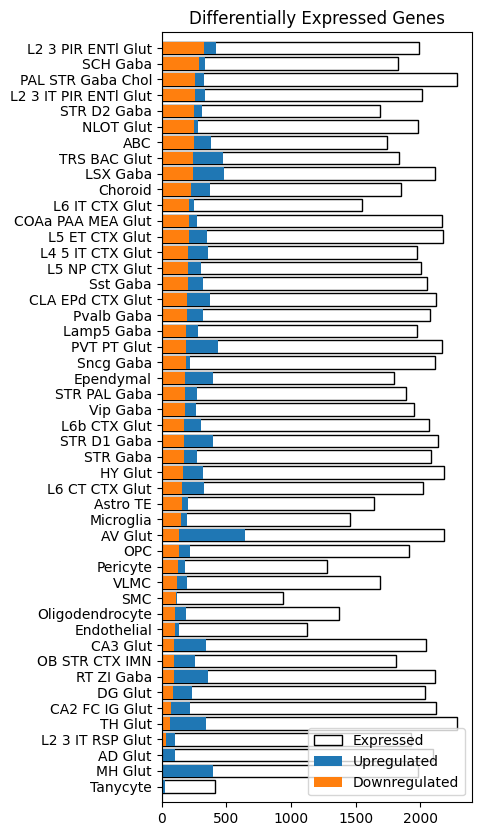

In [299]:
plt.figure(figsize=(4,10))
df_deg_quant.sort_values(by='Downregulated', inplace=True)
plt.barh(y = df_deg_quant['Celltype'], width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant['Celltype'], width=df_deg_quant['nb_DEG'], height = 0.8, label = "Upregulated")
plt.barh(y = df_deg_quant['Celltype'], width=df_deg_quant['Downregulated'], height = 0.8, label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.legend()
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')

## Volcano plot

/tmp/ipykernel_5022/3653181932.py:13: UserWarning:

Attempt to set non-positive ylim on a log-scaled axis will be ignored.



Text(0.5, 1.0, 'DEG: Astrocytes - Whole Brain')

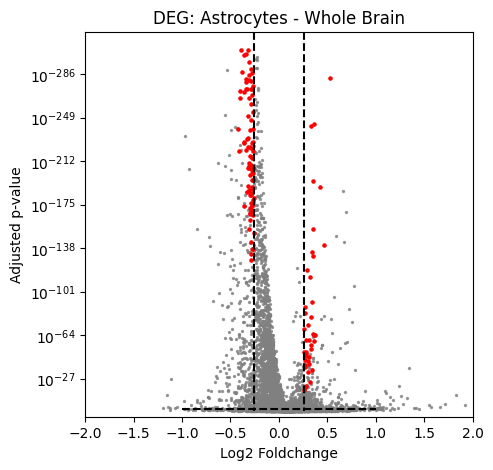

In [325]:
key = 'Astro TE'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(df_filter[key][df_filter[key]['logfoldchanges']>0]['names']):
#     plt.text(df_filter[key]['logfoldchanges'][idx], df_filter[key]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title("DEG: Astrocytes - Whole Brain")
# plt.savefig('Gallery/volcano_plot_SCN.svg')

In [384]:
df_filter[key].index = df_filter[key]['names']

KeyError: 'WM'

## DEG per regions

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/DEG_region/'
all_regions = os.listdir(directory_DEG)

In [8]:
cell_type_inregion = "SCH Gaba"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    celltype_inregion_DEG[region] = df[cell_type_inregion]

SCH
CTX
VLMC
HIPP
Ependymal
STR
HY
WM


In [12]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [13]:
for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == 'SD1']
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                           & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.15)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           ]

In [14]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
df_deg_quant.drop(['VLMC','Ependymal'], axis=0, inplace=True)
df_deg_quant

,Region,nb_DEG,Upregulated,Downregulated
Region,,,,
SCH,SCH,284,43,241
CTX,CTX,0,0,0
HY,HY,2,0,2
WM,WM,0,0,0


Text(0.5, 1.0, 'DEG: {cell_type_inregion} in different regions')

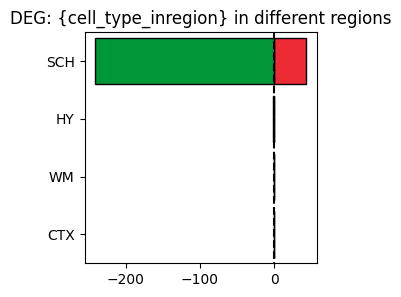

In [15]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title('DEG: {cell_type_inregion} in different regions')

In [17]:
celltype_inregion_DEG_filter['SCH'].sort_values(by="logfoldchanges")

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group
names,,,,,,,,
Nr4a3,Nr4a3,-12.376127,-0.743663,3.519204e-35,6.291834e-33,0.174485,0.290480,SD1
Olfm3,Olfm3,-11.444798,-0.724111,2.496869e-30,3.378196e-28,0.153471,0.255581,SD1
Peg10,Peg10,-14.612761,-0.664848,2.328847e-48,1.665458e-45,0.411590,0.579933,SD1
Odc1,Odc1,-13.431129,-0.625723,3.973079e-41,1.325949e-38,0.300573,0.454196,SD1
Per1,Per1,-11.551237,-0.615459,7.276562e-31,1.040756e-28,0.252176,0.372081,SD1
...,...,...,...,...,...,...,...,...
Marcks,Marcks,13.477661,0.601094,2.117123e-41,7.570228e-39,0.590533,0.523480,SD1
Vip,Vip,7.201977,0.604678,5.934561e-13,1.024428e-11,0.351730,0.289710,SD1
Nup98,Nup98,4.870345,0.642938,1.114034e-06,6.945024e-06,0.151136,0.119836,SD1


Text(0, 0.5, 'Adjusted p-value')

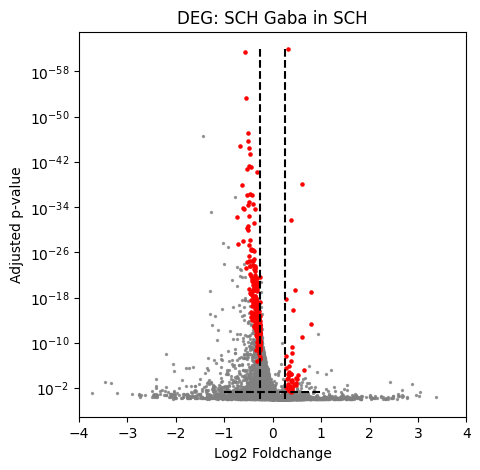

In [161]:
key = 'SCH'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
# for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges']>0]['names']):
#     plt.text(celltype_inregion_DEG_filter[key]['logfoldchanges'][idx], celltype_inregion_DEG_filter[key]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-4,4)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
# plt.savefig('Gallery/volcano_plot_SCN.svg')

In [165]:
list_genes = set(celltype_inregion_DEG_filter[key]['names'].values)
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp = set(celltype_inregion_DEG_filter[key]['names'].values)
    list_genes = list_genes.intersection(temp)
len(list_genes)


SCH
CTX
VLMC
Ependymal
HY
WM


0

In [354]:
temp = set("Sod1")

In [164]:
set(celltype_inregion_DEG_filter['SCH']['names'].values)

{'Abca7',
 'Adcy3',
 'Adipor1',
 'Agl',
 'Ago2',
 'Agpat4',
 'Aldoc',
 'Amfr',
 'Anapc2',
 'Ankrd11',
 'Anp32e',
 'Ap4s1',
 'Apc2',
 'Aplp2',
 'App',
 'Ar',
 'Arrb1',
 'Arrdc3',
 'Atp1b2',
 'Atp6ap2',
 'Atxn10',
 'Bcor',
 'Bex3',
 'Bin1',
 'Bsn',
 'Cacna1b',
 'Cacna2d1',
 'Cadps2',
 'Camk2a',
 'Camsap2',
 'Camta2',
 'Cap2',
 'Capn2',
 'Caprin1',
 'Ccar2',
 'Cct3',
 'Cct7',
 'Cd81',
 'Cdc42',
 'Cdipt',
 'Cdk5r2',
 'Celsr3',
 'Chd4',
 'Chmp3',
 'Clock',
 'Cntn1',
 'Commd1',
 'Comt',
 'Coro2b',
 'Crk',
 'Cry2',
 'Csnk1a1',
 'Csnk1d',
 'Csnk2a1',
 'Ctdsp1',
 'Ctnnb1',
 'Cttn',
 'Cx3cl1',
 'Cxxc5',
 'Cyb5a',
 'Dbn1',
 'Dbnl',
 'Dbp',
 'Ddit4',
 'Ddr1',
 'Disp2',
 'Dlg1',
 'Dlg4',
 'Dlx5',
 'Dner',
 'Dnttip1',
 'Dpy30',
 'Drd1',
 'Dusp4',
 'Eea1',
 'Efnb3',
 'Eif2a',
 'Eif4a3',
 'Eif4g1',
 'Emc10',
 'Emc3',
 'Emc6',
 'Eno1',
 'Epb41',
 'Epha5',
 'Fabp7',
 'Fam49b',
 'Fbxl20',
 'Fbxo21',
 'Fgfr3',
 'Fus',
 'G3bp1',
 'Gad2',
 'Gatad2b',
 'Gatd3a',
 'Gdf1',
 'Gipc1',
 'Gja1',
 'Gjb6',
 'Glg1',


## GO analysis

### Pre-process

In [22]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



  EXISTS: gene2go
go-basic.obo: fmt(1.2) rel(2025-06-01) 43,448 Terms


In [23]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

HMS:0:01:11.829169 612,814 annotations, 29,819 genes, 19,327 GOs, 1 taxids READ: gene2go 
MF 17,979 annotated mouse genes
CC 19,868 annotated mouse genes
BP 19,261 annotated mouse genes


In [24]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

26326


In [25]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method




Load BP Ontology Enrichment Analysis ...


 69% 18,219 of 26,326 population items found in association

Load CC Ontology Enrichment Analysis ...
 73% 19,338 of 26,326 population items found in association

Load MF Ontology Enrichment Analysis ...
 67% 17,586 of 26,326 population items found in association


In [26]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [27]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key].Symbol] = GeneID2nt_mouse[key].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [28]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

In [29]:
target_genes_up = list(celltype_inregion_DEG_filter['SCH'][celltype_inregion_DEG_filter['SCH']['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter['SCH'][celltype_inregion_DEG_filter['SCH']['logfoldchanges'] < 0]['names'])

In [30]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        


Load BP Ontology Enrichment Analysis ...


 69% 18,219 of 26,326 population items found in association

Load CC Ontology Enrichment Analysis ...
 73% 19,338 of 26,326 population items found in association

Load MF Ontology Enrichment Analysis ...
 67% 17,586 of 26,326 population items found in association

Runing BP Ontology Analysis: current study set of 41 IDs.
100%     41 of     41 study items found in association
100%     41 of     41 study items found in population(26326)
Calculating 12,691 uncorrected p-values using fisher_scipy_stats
  12,691 terms are associated with 18,219 of 26,326 population items
     568 terms are associated with     41 of     41 study items
  METHOD fdr_bh:
       0 GO terms found significant (< 0.1=alpha) (  0 enriched +   0 purified): statsmodels fdr_bh
       0 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 41 IDs.
 98%     40 of     41 study items found in associatio

### GO plot

In [207]:
df_go_up

,GO,term,class,p,p_corr,n_genes,n_study,n_go,study_genes
0,GO:0098978,glutamatergic synapse,cellular_component,9.428496e-07,0.001113,10,41,908,"[Sumo3, Ywhaz, Sumo1, Nsmf, Slc12a5, Ppp3r1, C..."
1,GO:0099523,presynaptic cytosol,cellular_component,1.199663e-06,0.001113,4,41,51,"[Sumo1, Sumo3, Marcks, Ppt1]"
2,GO:0030425,dendrite,cellular_component,6.957706e-06,0.003409,8,41,661,"[Ptprk, Sumo1, Nsmf, Prkaa2, Slc12a5, Ppt1, Ar..."
3,GO:0043025,neuronal cell body,cellular_component,7.350811e-06,0.003409,8,41,666,"[Ptprk, Fabp7, Prkaa2, Vip, Slc12a5, Gad2, Ppt..."


In [31]:
df_go_down

,GO,term,class,p,p_corr,n_genes,n_study,n_go,study_genes
0,GO:0007399,nervous system development,biological_process,1.157148e-10,0.000001,23,238,485,"[Dbn1, Ina, Pten, Epha5, Dner, Dlg1, Dlg4, Efn..."
1,GO:0006338,chromatin remodeling,biological_process,4.918255e-10,0.000002,18,238,309,"[Per1, Bcor, Kdm4b, Men1, Gatad2b, Smarca4, Se..."
2,GO:1902459,positive regulation of stem cell population ma...,biological_process,5.200853e-10,0.000002,9,238,49,"[Smarca4, Tead1, Smarcc1, Sin3a, Smarca2, Smar..."
3,GO:0045892,negative regulation of DNA-templated transcrip...,biological_process,1.287572e-09,0.000004,24,238,600,"[Zfp219, Men1, Ccar2, Set, Cry2, Lancl2, Chd4,..."
4,GO:0043410,positive regulation of MAPK cascade,biological_process,5.781098e-09,0.000015,15,238,241,"[Ctnnb1, Cd81, Map3k5, Ntsr2, Ndst1, App, Fgfr..."
...,...,...,...,...,...,...,...,...,...
160,GO:0003677,DNA binding,molecular_function,3.173170e-05,0.006250,34,238,1745,"[Zfp219, Men1, Set, Cry2, Aplp2, Chd4, G3bp1, ..."
161,GO:0001222,transcription corepressor binding,molecular_function,3.818494e-05,0.007166,6,238,69,"[Per1, Ctnnb1, Nr1d1, Eno1, Hdac5, Bsn]"
162,GO:0042826,histone deacetylase binding,molecular_function,4.038320e-05,0.007166,8,238,139,"[Bcor, Ywhae, Camta2, Wdtc1, Hdac5, Rac1, Chd4..."
163,GO:0042169,SH2 domain binding,molecular_function,5.267284e-05,0.008892,5,238,45,"[Crk, Ptk2, Sqstm1, Syp, Map2]"


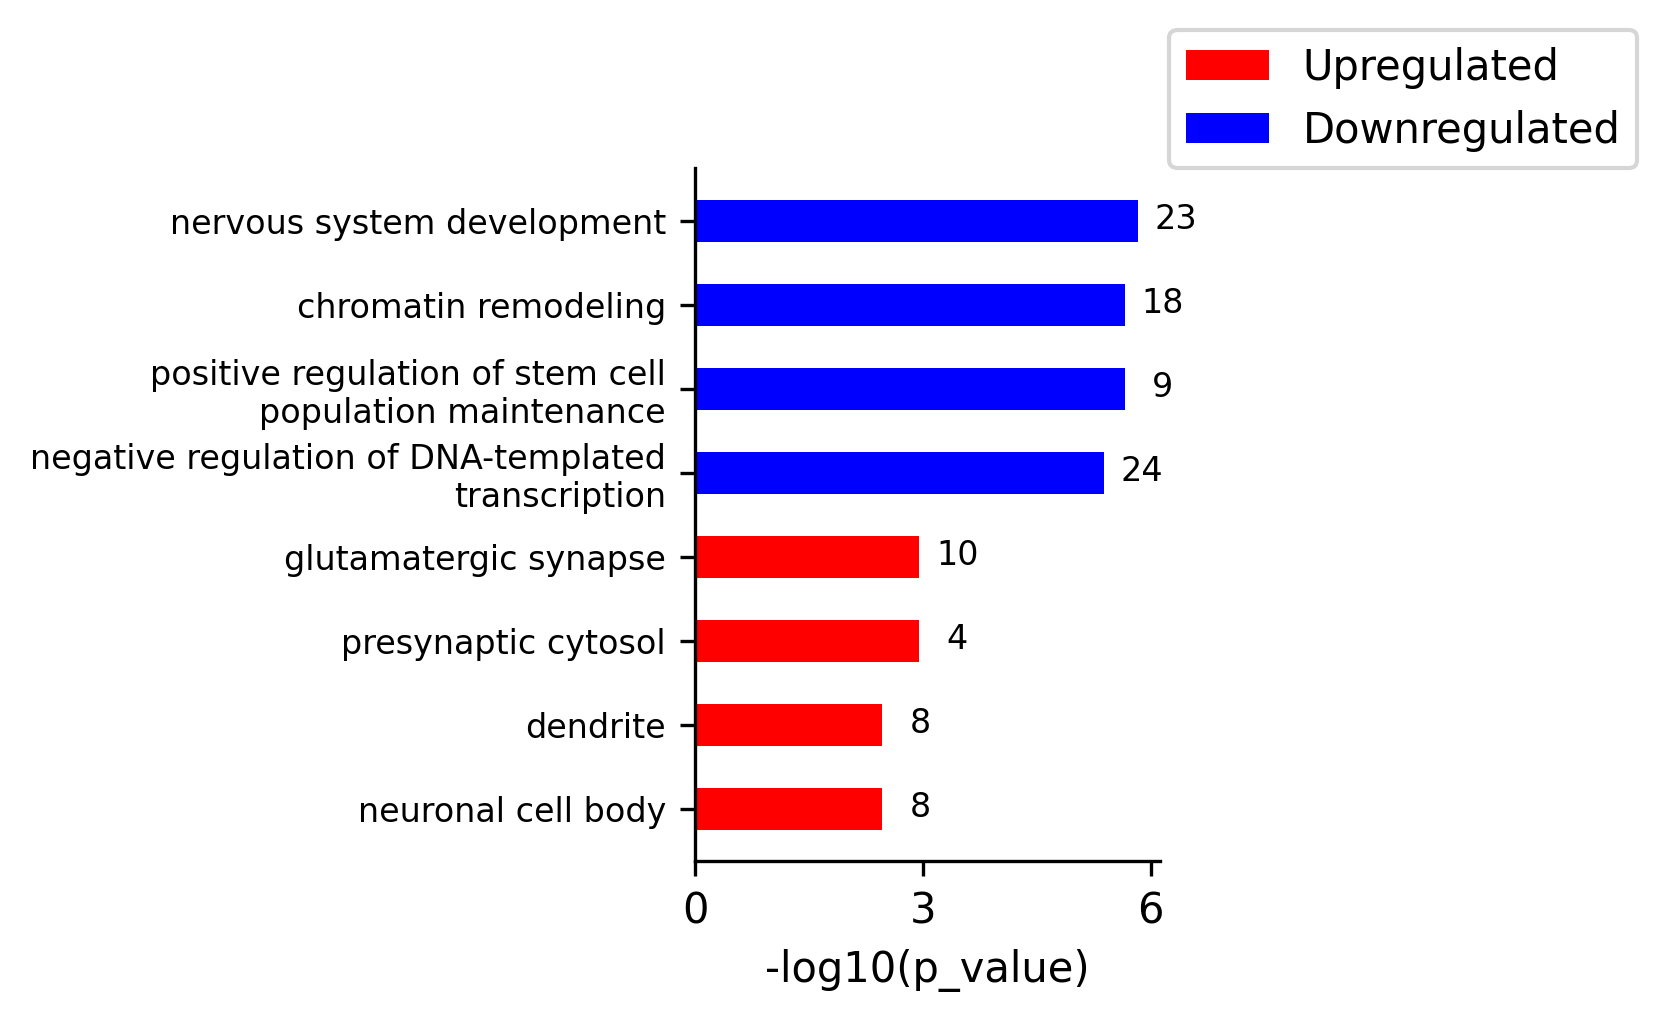

In [214]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(2,3),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10


up_labels = [s for s in df_go_up['term'][0:4]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:4]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:4]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:4]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:4]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:4]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'red', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'blue', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')

# plt.savefig('PRMT5_GO_plot.pdf',dpi=300,bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [94]:
print(*df_go[df_go['term']=="neuromuscular process controlling balance"]["study_genes"])

['Slc1a3', 'Nkx6-2', 'Atp2b2', 'Dlg4', 'Hexa', 'App', 'Gaa', 'Kcnma1', 'Nefl', 'Nlgn2', 'Aplp2']
